                Q      J_1s(2)      J_2s(2)      J_2p(2)      J_total
0    0.000000e+00 1.697653e+00 5.432489e+00 2.716244e+00 9.846386e+00
1    5.000000e-02 1.684984e+00 5.040898e+00 2.713634e+00 9.439516e+00
2    1.000000e-01 1.647725e+00 4.036459e+00 2.679066e+00 8.363250e+00
3    1.500000e-01 1.588031e+00 2.807825e+00 2.559790e+00 6.955646e+00
4    2.000000e-01 1.509207e+00 1.717422e+00 2.327831e+00 5.554460e+00
5    2.500000e-01 1.415344e+00 9.456876e-01 2.002633e+00 4.363664e+00
6    3.000000e-01 1.310899e+00 4.950740e-01 1.634678e+00 3.440652e+00
7    3.500000e-01 1.200300e+00 2.775800e-01 1.276017e+00 2.753897e+00
8    4.000000e-01 1.087614e+00 1.941536e-01 9.616098e-01 2.243378e+00
9    4.500000e-01 9.763232e-01 1.720512e-01 7.061018e-01 1.854476e+00
10   5.000000e-01 8.691982e-01 1.697653e-01 5.092958e-01 1.548259e+00
11   5.500000e-01 7.682732e-01 1.685084e-01 3.632424e-01 1.300024e+00
12   6.000000e-01 6.748887e-01 1.623089e-01 2.575334e-01 1.094731e+00
13   6.500000e-01 5.

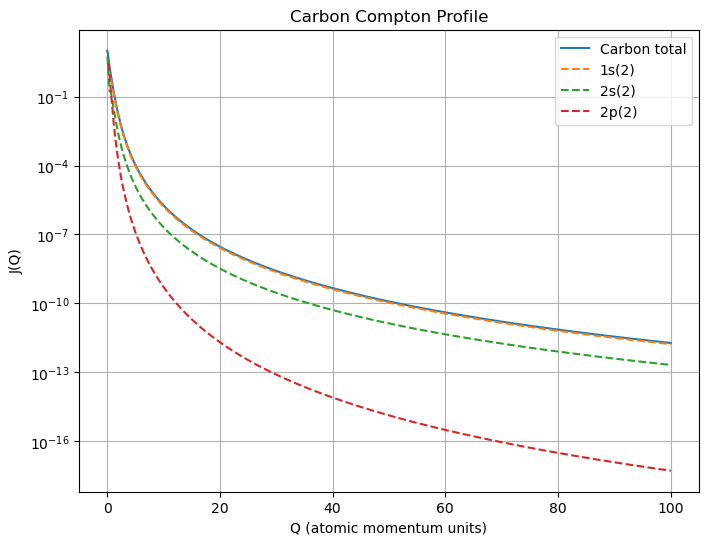

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Q values
Q = np.arange(0, 100.0 + 0.05, 0.05)

# These are placeholders.
# For accurate carbon, use tabulated Hartree-Fock values
# for 1s, 2s, and 2p orbitals.

def J_1s_carbon(Q):
    # approximate hydrogen-like shape, not exact carbon table
    return 2 * 8.0 / (3.0 * np.pi * (1.0 + Q**2)**3)

def J_2s_carbon(Q):
    # placeholder approximation
    return 2*128*(40*Q**4 - 10*Q**2 + 1) / (15*np.pi*(1.0 + 4*Q**2)**5)
# (J_2s(Q)=128/15π  (40Q^4-10Q^2+1)/(1+4Q^2 )^5 )

def J_2p_carbon(Q):
    # placeholder approximation
    return 2*64*(20*Q**2 + 1) / (15*np.pi*(1.0 + 4*Q**2)**5)

J1s = J_1s_carbon(Q)
J2s = J_2s_carbon(Q)
J2p = J_2p_carbon(Q)

J_total = J1s + J2s + J2p

table = pd.DataFrame({
    "Q": Q,
    "J_1s(2)": J1s,
    "J_2s(2)": J2s,
    "J_2p(2)": J2p,
    "J_total": J_total
})

pd.set_option("display.max_rows", None)
pd.set_option("display.float_format", "{:.6e}".format)

print(table)

table.to_csv("carbon_compton_profile.csv", index=False)

plt.figure(figsize=(8,6))
plt.plot(Q, J_total, label="Carbon total")
plt.plot(Q, J1s, "--", label="1s(2)")
plt.plot(Q, J2s, "--", label="2s(2)")
plt.plot(Q, J2p, "--", label="2p(2)")

plt.xlabel("Q (atomic momentum units)")
plt.ylabel("J(Q)")
plt.title("Carbon Compton Profile")
plt.yscale("log")
plt.grid(True)
plt.legend()
plt.show()